# **Activity Recognition in Older Adults using the HAR70+ Accelerometer Dataset**

#### **Course:** Fundamentals of Data Science and Engineering - Signal Processing
#### Master in Data Science and Engineering - FEUP

#### **Authors:**

202206098 - Beatriz Sonnemberg
\
202208293 - Beatriz Moreira
\
202207879 - Marta Costa



# Table of Contents

* **Introduction**
* **Methodological Structure**
* **1. Import Libraries**
* **2. Load Dataset**
* **3. Dataset Preparation**
    * 3.1) Label Mapping
    * 3.2) Sensor Columns
    * 3.3) Timestamp Conversion & Ordering
* **4. Exploratory Data Analysis**
    * 4.1) Missing Values
    * 4.2) Samples per Subject
    * 4.3) Activity Distribution
    * 4.4) Raw axis Distribution
    * 4.5) Correlation Heatmap
    * 4.6) Sample Duration per Subject and Activity
    * 4.7) Sampling Rate Estimation
    * 4.8) Timestamp Differences Histogram for a Subject
* **5. Data Preprocessing**
    * 5.1) Split data: Train and Test Subjects
    * 5.2) Signal normalization
* **6. Signals Visualization**
* **7. Feature Engineering**
    * 7.1) Feature Extraction Functions
    * 7.2) Feature Extraction
* **8. Baseline Classification Model: Random Forest**
    * 8.1) Prepare Data for Modeling
    * 8.2) Train Random Forest Classifier
    * 8.3) Evaluate Model Performance
* **9. Sensitivity Analysis and Model Robustness**
    * 9.1) Evaluation of Hyperparameters
    * 9.2) Effect of Window Size
    * 9.3) Best Model
* **10. Alternative Model: Support Vector Machine (SVM)**
    * 10.1) Train SVM Model Classifier
    * 10.2) Evaluate Model Performance
* **11. Conclusion and Future Work**

# **Introduction**


This notebook extends the analysis of the **HAR70+ dataset**, aiming to classify physical activities in older adults. It builds upon previous workflows by introducing **spectral similarity features** and comparing the performance of a **Random Forest (RF)** classifier against a **Support Vector Machine (SVM)**.
The main objective of this work is to construct and evaluate a robust Machine Learning model capable of classifying physical activities based on acceleration data.


**Dataset Description**

The Human Activity Recognition 70+ (HAR70+) dataset is a multivariate, time-series dataset specifically created for training machine learning models to classify the daily physical behavior of older adults. It comprises data from 18 fit-to-frail participants, aged 70 to 95 years, each wearing two 3-axial Axivity AX3 accelerometers. The sensors were attached to the right thigh and lower back, recording at a sampling rate of $50\text{Hz}$ over approximately 40 minutes during a semi-structured free-living protocol. The dataset contains over 2.2 million instances and 6 features (accelerations in x, y, z directions for both sensors). The activities were professionally annotated frame-by-frame using video recordings.

The dataset contains seven distinct annotated activities, with the main focus on locomotion and postural transitions: walking, shuffling, standing, sitting, lying, stairs (ascending), and stairs (descending). The raw data for each sample includes a timestamp, the three acceleration axes for the back sensor ($\text{back\_x, back\_y, back\_z}$), the three acceleration axes for the thigh sensor ($\text{thigh\_x, thigh\_y, thigh\_z}$), and the activity label. This specialized dataset is essential for building robust models for classifying physical behavior in this age demographic.


#### **Methodological Structure**

To achieve the objective, the development followed a rigorous data processing and modeling pipeline, including:

1. **Preprocessing**: Normalization of time series (Z-score) and verification of temporal and sampling stability.

2. **Feature Engineering**: Use of the Sliding Window technique to extract a comprehensive set of features in both the Time and Frequency domains.

3. **Advanced Features**: To optimize the distinction between classes, similarity metrics based on the Power Spectral Density (PSD) of the signals were introduced (as detailed in the second phase of the project).

4. **Modeling and Validation**: The **Random Forest (RF)** and **Support Vector Machine (SVM)** models were trained and evaluated using a strict subject-independent validation strategy, ensuring that the measured performance is a true reflection of the system's generalization capability.

The robustness of the solution is critically important, given the complexity of distinguishing between movements that can be more subtle or variable in elderly individuals.

## **1. Import Libraries**

We begin by preparing the development environment by importing all necessary libraries and loading the HAR70+ dataset for analysis.

In [ ]:
import os
import itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import skew, kurtosis, entropy
from scipy.fft import rfft, rfftfreq
from scipy.spatial.distance import euclidean

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from time import time

## **2. Load Dataset**

We use the **`load_all_subjects()`** function to:

*  Iterate through all CSV files in the specified directory;
*  Add a subject column identifying each participant;
*  Concatenate all data into a single DataFrame.

In [ ]:
DATA_DIR = Path.home() / "Desktop" / "SignalProcessing" / "har70plus"

if not DATA_DIR.exists():
    print(f"Directory does not exist: {DATA_DIR}")
else:
    print(f"Using directory: {DATA_DIR}")

# Load all CSV files
def load_all_subjects(path):
    dfs = []
    for file in os.listdir(path):
        if file.endswith(".csv"):
            file_path = path / file
            df = pd.read_csv(file_path)
            df["subject"] = file.split(".")[0]
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# Load the dataset
data = load_all_subjects(DATA_DIR)

print("Dataset shape:", data.shape)
display(data.head())

Using directory: C:\Users\beatr\Desktop\SignalProcessing\har70plus
Dataset shape: (2259597, 9)


,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject
0,2021-03-24 14:42:03.839,-0.999023,-0.063477,0.140625,-0.980469,-0.112061,-0.048096,6,501
1,2021-03-24 14:42:03.859,-0.980225,-0.079346,0.140625,-0.961182,-0.121582,-0.051758,6,501
2,2021-03-24 14:42:03.880,-0.950195,-0.076416,0.140625,-0.949463,-0.080566,-0.067139,6,501
3,2021-03-24 14:42:03.900,-0.954834,-0.059082,0.140381,-0.957520,-0.046143,-0.050781,6,501
4,2021-03-24 14:42:03.920,-0.972412,-0.042969,0.142822,-0.977051,-0.023682,-0.026611,6,501


## **3. Dataset Preparation**

We checked the data types of each column (**dtypes**) to ensure that:

*   The accelerometer axes (x, y, z) are numeric (float/int);
*   The timestamps are strings (for later conversion);
*   The activity labels are integers.

In [ ]:
print("Column data types:")
print(data.dtypes)
print("\n")

Column data types:
timestamp     object
back_x       float64
back_y       float64
back_z       float64
thigh_x      float64
thigh_y      float64
thigh_z      float64
label          int64
subject       object
dtype: object




### 3.1) Label Mapping

Before training the models, textual activity labels are converted into numerical codes (Label Encoding). The numerical activity labels are mapped into names and a new column with the activity names is added.

In [ ]:
label_map = {
    1: "walking",
    3: "shuffling",
    4: "stairs_ascending",
    5: "stairs_descending",
    6: "standing",
    7: "sitting",
    8: "lying"
}

data["activity_name"] = data["label"].map(label_map)

### 3.2) Sensor Columns

In [ ]:
sensor_cols = [
    "back_x", "back_y", "back_z",
    "thigh_x", "thigh_y", "thigh_z"
]

### 3.3) Timestamp Conversion & Ordering

The timestamp column was converted from string format to a proper datetime object, and data for each subject was sorted chronologically to ensure temporal coherence.

This step is essential for any time-series segmentation or activity transition analysis.


In [ ]:
# Convert timestamp column to datetime
data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce")

# Sort by subject → timestamp
data = data.sort_values(["subject", "timestamp"]).reset_index(drop=True)

print("Done: timestamp converted and dataset sorted.")
print(data[["timestamp", "subject"]].head())

Done: timestamp converted and dataset sorted.
                timestamp subject
0 2021-03-24 14:42:03.839     501
1 2021-03-24 14:42:03.859     501
2 2021-03-24 14:42:03.880     501
3 2021-03-24 14:42:03.900     501
4 2021-03-24 14:42:03.920     501


## **4. Exploratory Data Analysis**

### 4.1) Missing Values

We analyzed missing values ​to identify gaps in the data that could compromise the quality of the model. The **`isna().sum()`** function counts null values ​​per column. We verified that the dataset has no missing values.

In [ ]:
print("Missing values per column:")
print(data.isna().sum())
print("\n")

Missing values per column:
timestamp        0
back_x           0
back_y           0
back_z           0
thigh_x          0
thigh_y          0
thigh_z          0
label            0
subject          0
activity_name    0
dtype: int64




### 4.2) Samples per Subject

We analized the number of samples per participant using:

* **`value_counts()`** - counting samples per subject;
* Bar chart (countplot) for visualizing the distribution.

The analysis of this distribution is of significant importance because it allows us to identify imbalances that may bias the model towards subjects with more data.


=== Samples per Subject ===


subject
501    103860
502    131367
503    116413
504    150758
505     87006
506    122714
507    120125
508    130494
509    121763
510    122061
511    128063
512    119310
513    123599
514    101510
515    153517
516    138278
517    147045
518    141714
Name: count, dtype: int64

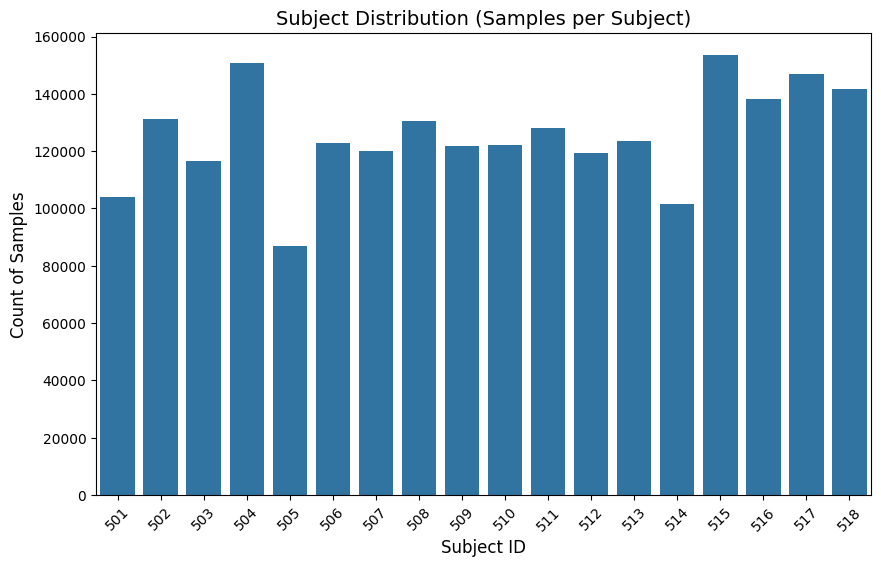

In [ ]:
print("\n=== Samples per Subject ===")
display(data["subject"].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.countplot(x='subject', data=data)
plt.title('Subject Distribution (Samples per Subject)', fontsize=14)
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Count of Samples', fontsize=12)
plt.xticks(rotation=45)
plt.show()

The distribution of samples per subject shows that most subjects have a consistent number of samples, generally ranging between 120000 and 155000, although subjects 505 and 515 present notable variation, with 505 having significantly fewer samples (87086) and 515 presenting the highest count (153517).

### 4.3) Activity Distribution

This code calculates the distribution of each activity in the dataset, including the number of samples and their percentage of the total data. Finally, it displays a table showing this distribution.






In [ ]:
counts = data["label"].value_counts().sort_index()

activity_table = pd.DataFrame({
    "Activity Code": counts.index,
    "Activity Name": counts.index.map(label_map),
    "Samples": counts.values,
    "Percentage (%)": (counts.values / len(data) * 100).round(2)
})

print("=== Activity Distribution Table ===")
display(activity_table)

=== Activity Distribution Table ===


,Activity Code,Activity Name,Samples,Percentage (%)
0,1,walking,1079312,47.77
1,3,shuffling,66058,2.92
2,4,stairs_ascending,4560,0.20
3,5,stairs_descending,4978,0.22
4,6,standing,418055,18.50
5,7,sitting,483452,21.40
6,8,lying,203182,8.99


We also created a bar plot representation showing the percentage of each activity in the dataset. The code calculates the percentage of samples for each activity, sorts them in descending order, and then plots them as a bar chart.

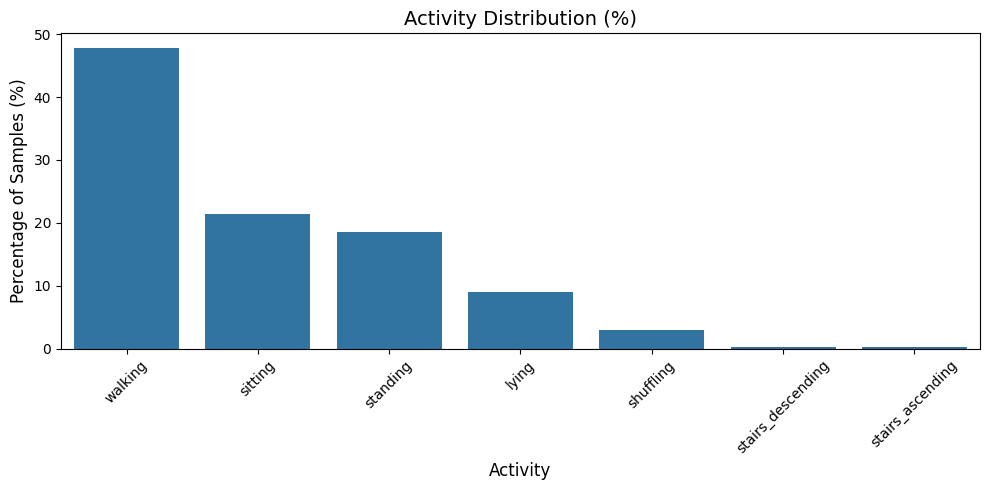

In [ ]:
activity_percent = (
    data["activity_name"].value_counts(normalize=True).sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=activity_percent.index,
    y=activity_percent.values
)

plt.title("Activity Distribution (%)", fontsize=14)
plt.xlabel("Activity", fontsize=12)
plt.ylabel("Percentage of Samples (%)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the bar plot, we observe the following:

The activity labeled **walking** accounts for the largest portion of the dataset, representing nearly **50%** of the total samples. Other activities such as sitting and standing also have significant percentages, with **sitting** representing around **30%** and **standing** about **20%**.

In contrast, activities like **shuffling**, **stairs_descending**, and **stairs_ascending** contribute a very small portion of the data, each with **less than 5%**. **Lying** falls in between, showing a modest share of the total samples.

This distribution suggests that the dataset is imbalanced and heavily dominated by activities like walking and sitting, while more dynamic actions, such as shuffling and stair climbing, are underrepresented.

### 4.4) Raw axis Distribution

Here, we generated a boxplot to visualize the distribution of raw accelerometer signals across different sensor columns. The boxplot displays the spread of acceleration values for each sensor, with the y-axis representing the acceleration in gravitational units (g).
By visualizing the boxplot, we can observe the distribution, potential outliers, and overall range of the accelerometer signals, helping us understand the variation and quality of the sensor data.

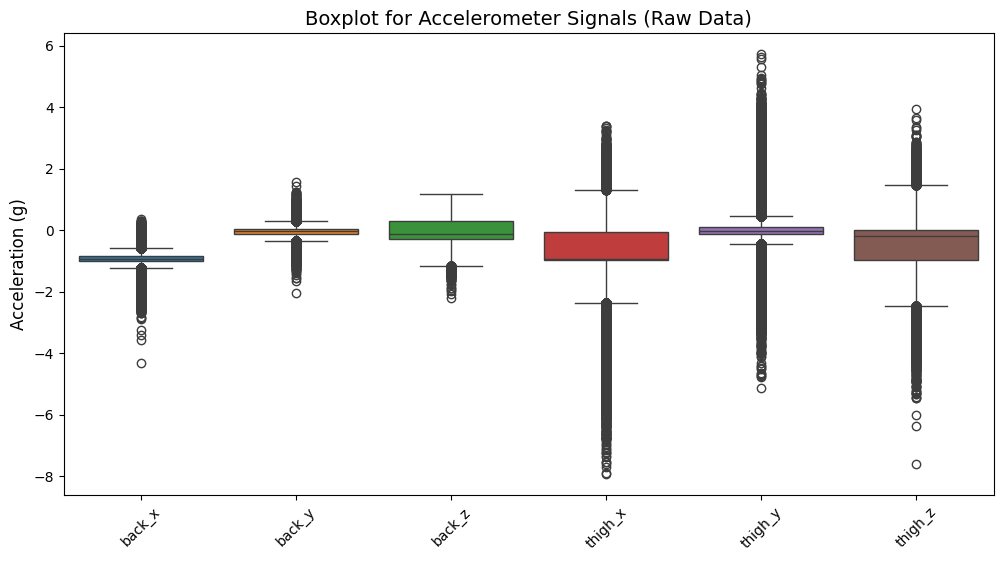

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[sensor_cols])
plt.title('Boxplot for Accelerometer Signals (Raw Data)', fontsize=14)
plt.ylabel('Acceleration (g)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Based on the boxplot, we observe the following patterns in the accelerometer data for the different sensor axes:

- The **back_x**, **back_y**, and **back_z** sensors show a relatively small range of acceleration values, with most data points clustered near zero. However, there are significant outliers on both the positive and negative sides, particularly for the back_x sensor.

- The **thigh_x**, **thigh_y**, and **thigh_z** sensors exhibit a broader range of acceleration values. These axes show a higher variation, with the presence of many outliers, especially in the thigh_x and thigh_y sensors, suggesting that there are larger fluctuations or noise in the data for these sensors.

Overall, this boxplot helps in identifying the spread of the data, outliers, and potential issues with sensor calibration or noise.

### 4.5) Correlation Heatmap

This code generates a **heatmap** to visualize the correlation between different accelerometer signals across the sensor axes. The `corr()` function calculates the pairwise correlation coefficients between the sensor columns, which indicates the degree to which each sensor's readings are related to one another.

This visualization helps identify which sensors have similar or opposite readings, and can be useful for detecting redundancy in the data or understanding how sensor readings may influence each other.

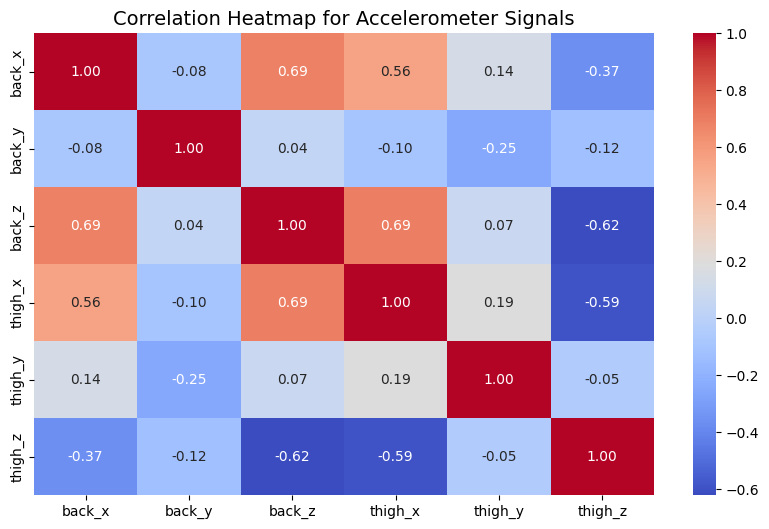

In [ ]:
correlation_matrix = data[sensor_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Accelerometer Signals', fontsize=14)
plt.show()

Based on the correlation heatmap, the relationships between the sensor axes are primarily structured by the body's biomechanics and sensor orientation.

**Key Correlation Patterns and Causes**

1.  **Moderate to Strong Positive Cross-Sensor Correlation:**
    * **Observation:** There are moderate to strong positive correlations between the back sensors (e.g., $\text{back\_x}$) and the thigh sensors (e.g., $\text{thigh\_x}$ and $\text{thigh\_z}$).
    * **Cause:** This coupling is due to **shared movement dynamics** and **postural shifts**. Changes in the overall body posture (like bending or sitting) simultaneously affect the orientation of both the back and thigh sensors relative to gravity, leading to correlated mean acceleration readings along these axes.

2.  **Significant Negative Correlation:**
    * **Observation:** The thigh $Z$-axis shows notable negative correlations with the back $Z$-axis ($-0.62$), the thigh $X$-axis ($-0.59$), and the back $X$-axis ($-0.37$).
    * **Cause:** This strong negative relationship indicates an **anti-phase mechanical coupling**, most evident during cyclical activities like walking. As the thigh moves forward (increasing acceleration on the thigh $Z$-axis), the upper body or trunk often counter-rotates or stabilizes, causing the corresponding back axis to move in the opposite direction.


### Overall Implication

The mixed pattern of positive, negative, and weak correlations indicates that while some sensor axes provide **redundant information** (high positive correlation, useful for postural features), others provide **complementary, anti-phase information** (negative correlation, highly valuable for dynamic features like gait). The low correlation of the $Y$-axis confirms it provides unique data that is structurally independent of the main postural and forward movement measurements.

### 4.6) Sample Duration per Subject and Activity

This section calculates the total duration (in seconds) of recorded samples for each subject and activity. The resulting table and heatmap help identify which activities have sufficient data for analysis and highlight any potential imbalances across subjects or activities.



--- Duration Table (seconds) ---


,walking,shuffling,stairs_ascending,stairs_descending,standing,sitting,lying
subject,,,,,,,
501,1257.44,37.52,1.84,10.08,287.52,291.24,191.56
502,1400.16,106.00,0.00,3.12,418.22,455.60,244.24
503,1107.68,103.96,0.00,0.00,426.82,377.52,312.28
504,1263.76,91.24,4.04,3.68,950.68,581.16,120.60
505,486.28,35.36,0.00,0.00,346.36,604.52,267.60
506,1350.60,64.12,2.88,2.60,299.96,509.52,224.60
507,1292.52,39.84,5.16,11.16,532.62,325.32,195.88
508,1502.96,41.92,13.44,14.48,292.32,449.88,294.88
509,1112.20,56.64,14.84,12.08,460.78,550.20,228.52


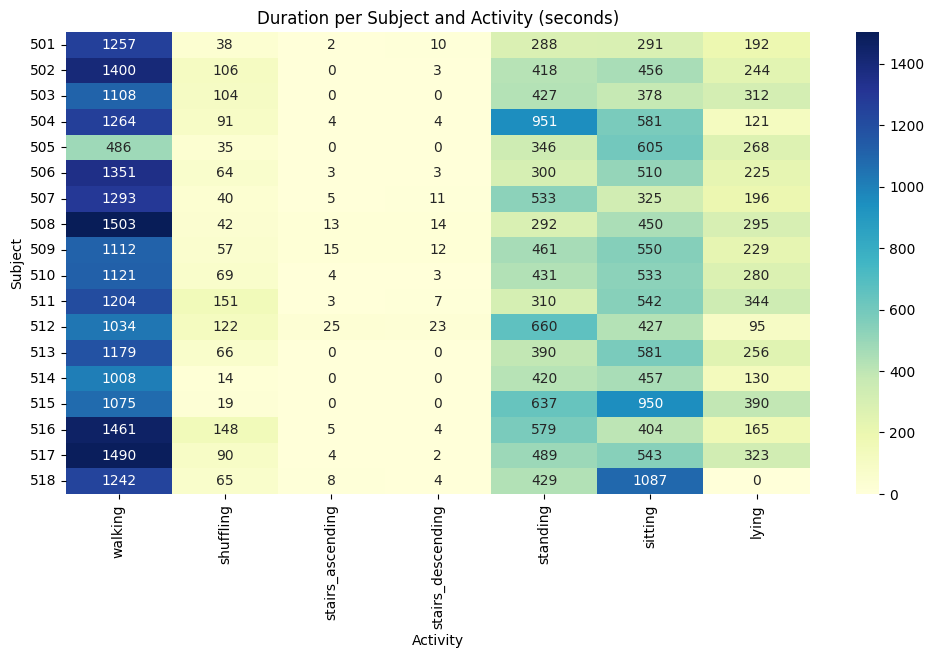

In [ ]:
def analyze_sample_duration(df, fs=50):

    # Count samples per subject and activity
    sample_counts = df.groupby('subject')['label'].value_counts().unstack(fill_value=0)

    # Convert counts to duration in seconds
    duration_table = sample_counts / fs

    # Map activity codes to names using existing label_map
    duration_table.columns = [label_map.get(col, col) for col in duration_table.columns]

    return duration_table

df_duration = analyze_sample_duration(data, fs=50)

print("\n--- Duration Table (seconds) ---")
display(df_duration)

plt.figure(figsize=(12,6))
sns.heatmap(df_duration, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Duration per Subject and Activity (seconds)")
plt.xlabel("Activity")
plt.ylabel("Subject")
plt.show()


The **heatmap** shows the duration (in seconds) each subject spent on various activities.

- **Walking** and **standing** generally have the longest durations, with some subjects like Subject 508 spending over 1500 seconds walking.

- **Sitting** also has long durations, especially for Subject **518**, who spent 1087 seconds sitting.

- Activities like **shuffling** and **stairs ascending** are typically shorter in duration, with many subjects spending less than 50 seconds on them.

- **Lying** has variable durations, with some subjects spending little to no time lying down.

Overall, the heatmap reveals different activity patterns across subjects, with some spending more time on certain activities like sitting or walking. This is related to the phisical capacity of each person in the study.

### 4.7) Sampling Rate Estimation


The time difference between consecutive samples was calculated using the `diff()` method on the timestamps. Based on these differences, the sampling rate for each subject was estimated by calculating the median of these time intervals and converting it to samples per second (Hz).


In [ ]:
sampling_rates = {}

for subject, df_sub in data.groupby("subject"):
    diffs = df_sub["timestamp"].diff().dt.total_seconds()
    median_sr = round(1 / diffs.median(), 2)  # samples per second
    sampling_rates[subject] = median_sr

sampling_rates_df = pd.DataFrame.from_dict(
    sampling_rates, orient="index", columns=["sampling_rate_Hz"]
)

display(sampling_rates_df)

,sampling_rate_Hz
501,50.0
502,50.0
503,50.0
504,50.0
505,50.0
506,50.0
507,50.0
508,50.0
509,50.0
510,50.0



The results showed that all subjects had a stable sampling rate of **50 Hz**, which aligns with the specification of the Axivity AX3 accelerometer.

This consistency in the sampling frequency validates the reliability of the recordings and ensures that fixed-length sliding windows can be constructed for further analysis.

### 4.8) Timestamp Differences Histogram for a Subject

The code processes the dataset by grouping it by subject, sorting the data by timestamp, and calculating the time difference between consecutive samples. The median sampling rate is then used to determine the expected sampling interval. The code identifies gaps in the data that exceed a threshold, which is set as three times the expected interval. If any gaps are found, they are reported along with the gap duration.

This process helps in detecting irregularities or missing data that could impact the analysis, ensuring the data integrity is maintained.

In [ ]:
for subject, df_sub in data.groupby('subject'):
    df_sub = df_sub.sort_values('timestamp')
    diffs = df_sub['timestamp'].diff().dt.total_seconds()

    # Identify gaps larger than expected sampling interval (1 / median sampling rate)
    median_sr = 1 / diffs.median()  # samples per second
    expected_interval = 1 / median_sr
    gap_threshold = 3 * expected_interval  # e.g., 3 times expected interval

    gaps = df_sub[diffs > gap_threshold]

    print(f"\nSubject: {subject}")
    if len(gaps) == 0:
        print("No significant gaps detected.")
    else:
        print(f"Found {len(gaps)} gaps exceeding {gap_threshold:.2f} seconds:")


Subject: 501
Found 10 gaps exceeding 0.06 seconds:

Subject: 502
Found 12 gaps exceeding 0.06 seconds:

Subject: 503
Found 14 gaps exceeding 0.06 seconds:

Subject: 504
Found 16 gaps exceeding 0.06 seconds:

Subject: 505
Found 7 gaps exceeding 0.06 seconds:

Subject: 506
Found 18 gaps exceeding 0.06 seconds:

Subject: 507
Found 15 gaps exceeding 0.06 seconds:

Subject: 508
Found 13 gaps exceeding 0.06 seconds:

Subject: 509
Found 19 gaps exceeding 0.06 seconds:

Subject: 510
Found 14 gaps exceeding 0.06 seconds:

Subject: 511
Found 12 gaps exceeding 0.06 seconds:

Subject: 512
Found 11 gaps exceeding 0.06 seconds:

Subject: 513
Found 20 gaps exceeding 0.06 seconds:

Subject: 514
Found 14 gaps exceeding 0.06 seconds:

Subject: 515
Found 16 gaps exceeding 0.06 seconds:

Subject: 516
Found 16 gaps exceeding 0.06 seconds:

Subject: 517
Found 20 gaps exceeding 0.06 seconds:

Subject: 518
Found 8 gaps exceeding 0.06 seconds:


Based on the timestamp difference distribution, a threshold of 0.06 s (three times the nominal sampling interval) was adopted to identify meaningful temporal gaps while avoiding sensitivity to minor acquisition jitter.

A timestamp difference analysis revealed the presence of small temporal gaps (>0.06 s) across all subjects, with an average of approximately 10–20 occurrences per subject. Given the nominal sampling rate of 50 Hz (Δt ≈ 0.02 s), these gaps correspond to at most 2–3 missing samples and represent a negligible fraction of the total data. As the proposed feature extraction is based on sliding windows and aggregated statistics, these small irregularities are unlikely to impact the model performance. Therefore, no explicit correction or interpolation was applied.

We will ignore these timestamps where the gap exceeds 0.06 seconds, as they do not significantly affect the overall data quality or the model's ability to learn from the continuous activity patterns. The focus is on maintaining data integrity and ensuring that the feature extraction process is robust to small temporal inconsistencies.

## **5. Data Preprocessing**

### 5.1) Split data: Train and Test Subjects

The evaluation of the Machine Learning model was based on a rigorous division of the data into **Training** and **Test** sets. This is fundamental to prevent **overfitting** and ensure the model's generalization capability.

**Splitting Criterion**

The dataset, comprising data from 18 subjects, was partitioned using a subject-wise split methodology.


**Test Set:** 3 subjects (502, 511, and 507) were exclusively reserved for the final model assessment.

**Training Set:** The remaining 15 subjects were utilized for model development and training.

The selection of the specific test subjects (S02, S11, S07) was strategic to simulate a real-world deployment scenario for a new user. This methodology allows for the evaluation of cross-subject generalization, testing the model's ability to accurately predict the activities of individuals never seen during the training phase.

In [ ]:
TEST_SUBJECTS = ["502", "511", "507"]

data_train = data[~data["subject"].isin(TEST_SUBJECTS)].copy()
data_test  = data[data["subject"].isin(TEST_SUBJECTS)].copy()

print("Subjects treino:", data_train["subject"].nunique())
print("Subjects teste :", data_test["subject"].nunique())

Subjects treino: 15
Subjects teste : 3


**Importance of Early Splitting**

The data separation was performed prior to the segmentation into time windows. This step is critical to **prevent data leakage**. Had the split occurred after segmentation, adjacent segments from the same time series could contaminate the training and test sets, leading to an unrealistically optimistic performance evaluation.

### 5.2) Signal normalization


The accelerometer data from all sensor axes were standardized using **z-score normalization**. While tree-based models do not strictly require normalization, it provides several benefits. Normalization improves **numerical stability**, ensuring that the model performs consistently. It also allows for better **comparability** across different sensor axes, making it easier to analyze the relationships between them. Additionally, normalization enhances the **performance of frequency-domain feature extraction** by ensuring that features with large differences in magnitude do not dominate the model. This step ensures that no single sensor or axis introduces bias into the model, allowing it to learn more effectively.

In [ ]:
scaler_signal = StandardScaler()
data_train[sensor_cols] = scaler_signal.fit_transform(data_train[sensor_cols])
data_test[sensor_cols]  = scaler_signal.transform(data_test[sensor_cols])

print("Signals normalized (z-score).")

Signals normalized (z-score).


## **6. Signals Visualization**

We decided to create the `plot_subject_6_axes` function to visualize the accelerometer data from all six axes (x, y, z for both the back and thigh sensors) for a given subject. This approach allows for a comprehensive view of the sensor signals, making it easier to analyze the data across different axes and time periods.

The process consists of several steps:

- **Data Selection**: The function filters the dataset to extract data for the specified subject.

- **Time Calculation**: It calculates the time difference in seconds relative to the first timestamp, providing a clear time-based x-axis.

- **Fixed Y-Limit**: A y-axis limit of +/- 15g is set to ensure all signal peaks are captured, allowing for easy cross-axis comparison.

- **Activity Highlighting**: The function uses colored background segments to visually distinguish between different activities. Each activity is assigned a unique color, which helps in recognizing transitions between activities.

- **Plotting**: The data for each accelerometer axis is plotted on individual subplots. The acceleration signals are shown as black lines, with activity periods highlighted by transparent color spans. This allows for a clear visualization of how the acceleration data changes over time.

- **Zoom Option**: If a time range is specified, the x-axis is zoomed into that interval, offering a closer look at specific moments in time.

This function allows for easy comparison of sensor data across axes and activities, helping to identify patterns, trends, or anomalies within the data for each subject.

In [ ]:
def plot_subject_6_axes(df, subject_id, label_map, time_range=None):
    """
    Plots the 6 accelerometer axes stacked vertically (6 rows, 1 column).
    """

    df_sub = df[df["subject"] == str(subject_id)].copy()
    if df_sub.empty:
        print(f"Subject {subject_id} not found.")
        return

    df_sub["time_seconds"] = (df_sub["timestamp"] - df_sub["timestamp"].iloc[0]).dt.total_seconds()

    # Fixed Y-limit: +/- 15g to capture all signal peaks and allow cross-axis comparison
    Y_LIMIT = (-15, 15)

    unique_activities = list(label_map.values())
    palette = sns.color_palette("tab10", n_colors=len(unique_activities))
    activity_colors = {act: col for act, col in zip(unique_activities, palette)}

    fig, axes = plt.subplots(6, 1, figsize=(28, 18), sharex=False)
    fig.suptitle(f"Subject {subject_id} — Acceleration Signals (6 Axes)", fontsize=16, y=0.99)

    # Calculate contiguous blocks of activity
    activity_blocks = (df_sub["activity_name"] != df_sub["activity_name"].shift()).cumsum()

    for i, axis in enumerate(sensor_cols):
        ax = axes[i]

        # Plot signal line
        ax.plot(df_sub["time_seconds"], df_sub[axis], color="black", linewidth=0.5)

        for act, color in activity_colors.items():
            for block_id, block_df in df_sub.groupby(activity_blocks):
                if block_df["activity_name"].iloc[0] == act:
                    ax.axvspan(block_df["time_seconds"].iloc[0],
                               block_df["time_seconds"].iloc[-1],
                               color=color, alpha=0.3)

        ax.set_title(axis.upper(), loc='left', fontsize=12)

        if i == 0:
            ax.set_ylabel("Acceleration (g)")
        else:
            ax.set_ylabel("")

        ax.set_ylim(Y_LIMIT)
        ax.grid(axis='y', alpha=0.3)

        # ZOOM: Set X-axis limit for zoom if time_range is provided
        if time_range:
            ax.set_xlim(time_range)

        ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

        if i == len(sensor_cols) - 1:
            ax.set_xlabel("Time (seconds)")
        else:
            ax.set_xlabel("")

    handles = [mpatches.Patch(color=color, alpha=0.3, label=act) for act, color in activity_colors.items()]
    fig.legend(handles=handles,
               loc='upper center',
               bbox_to_anchor=(0.5, 0.98),
               ncol=len(activity_colors),
               title="Activity")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

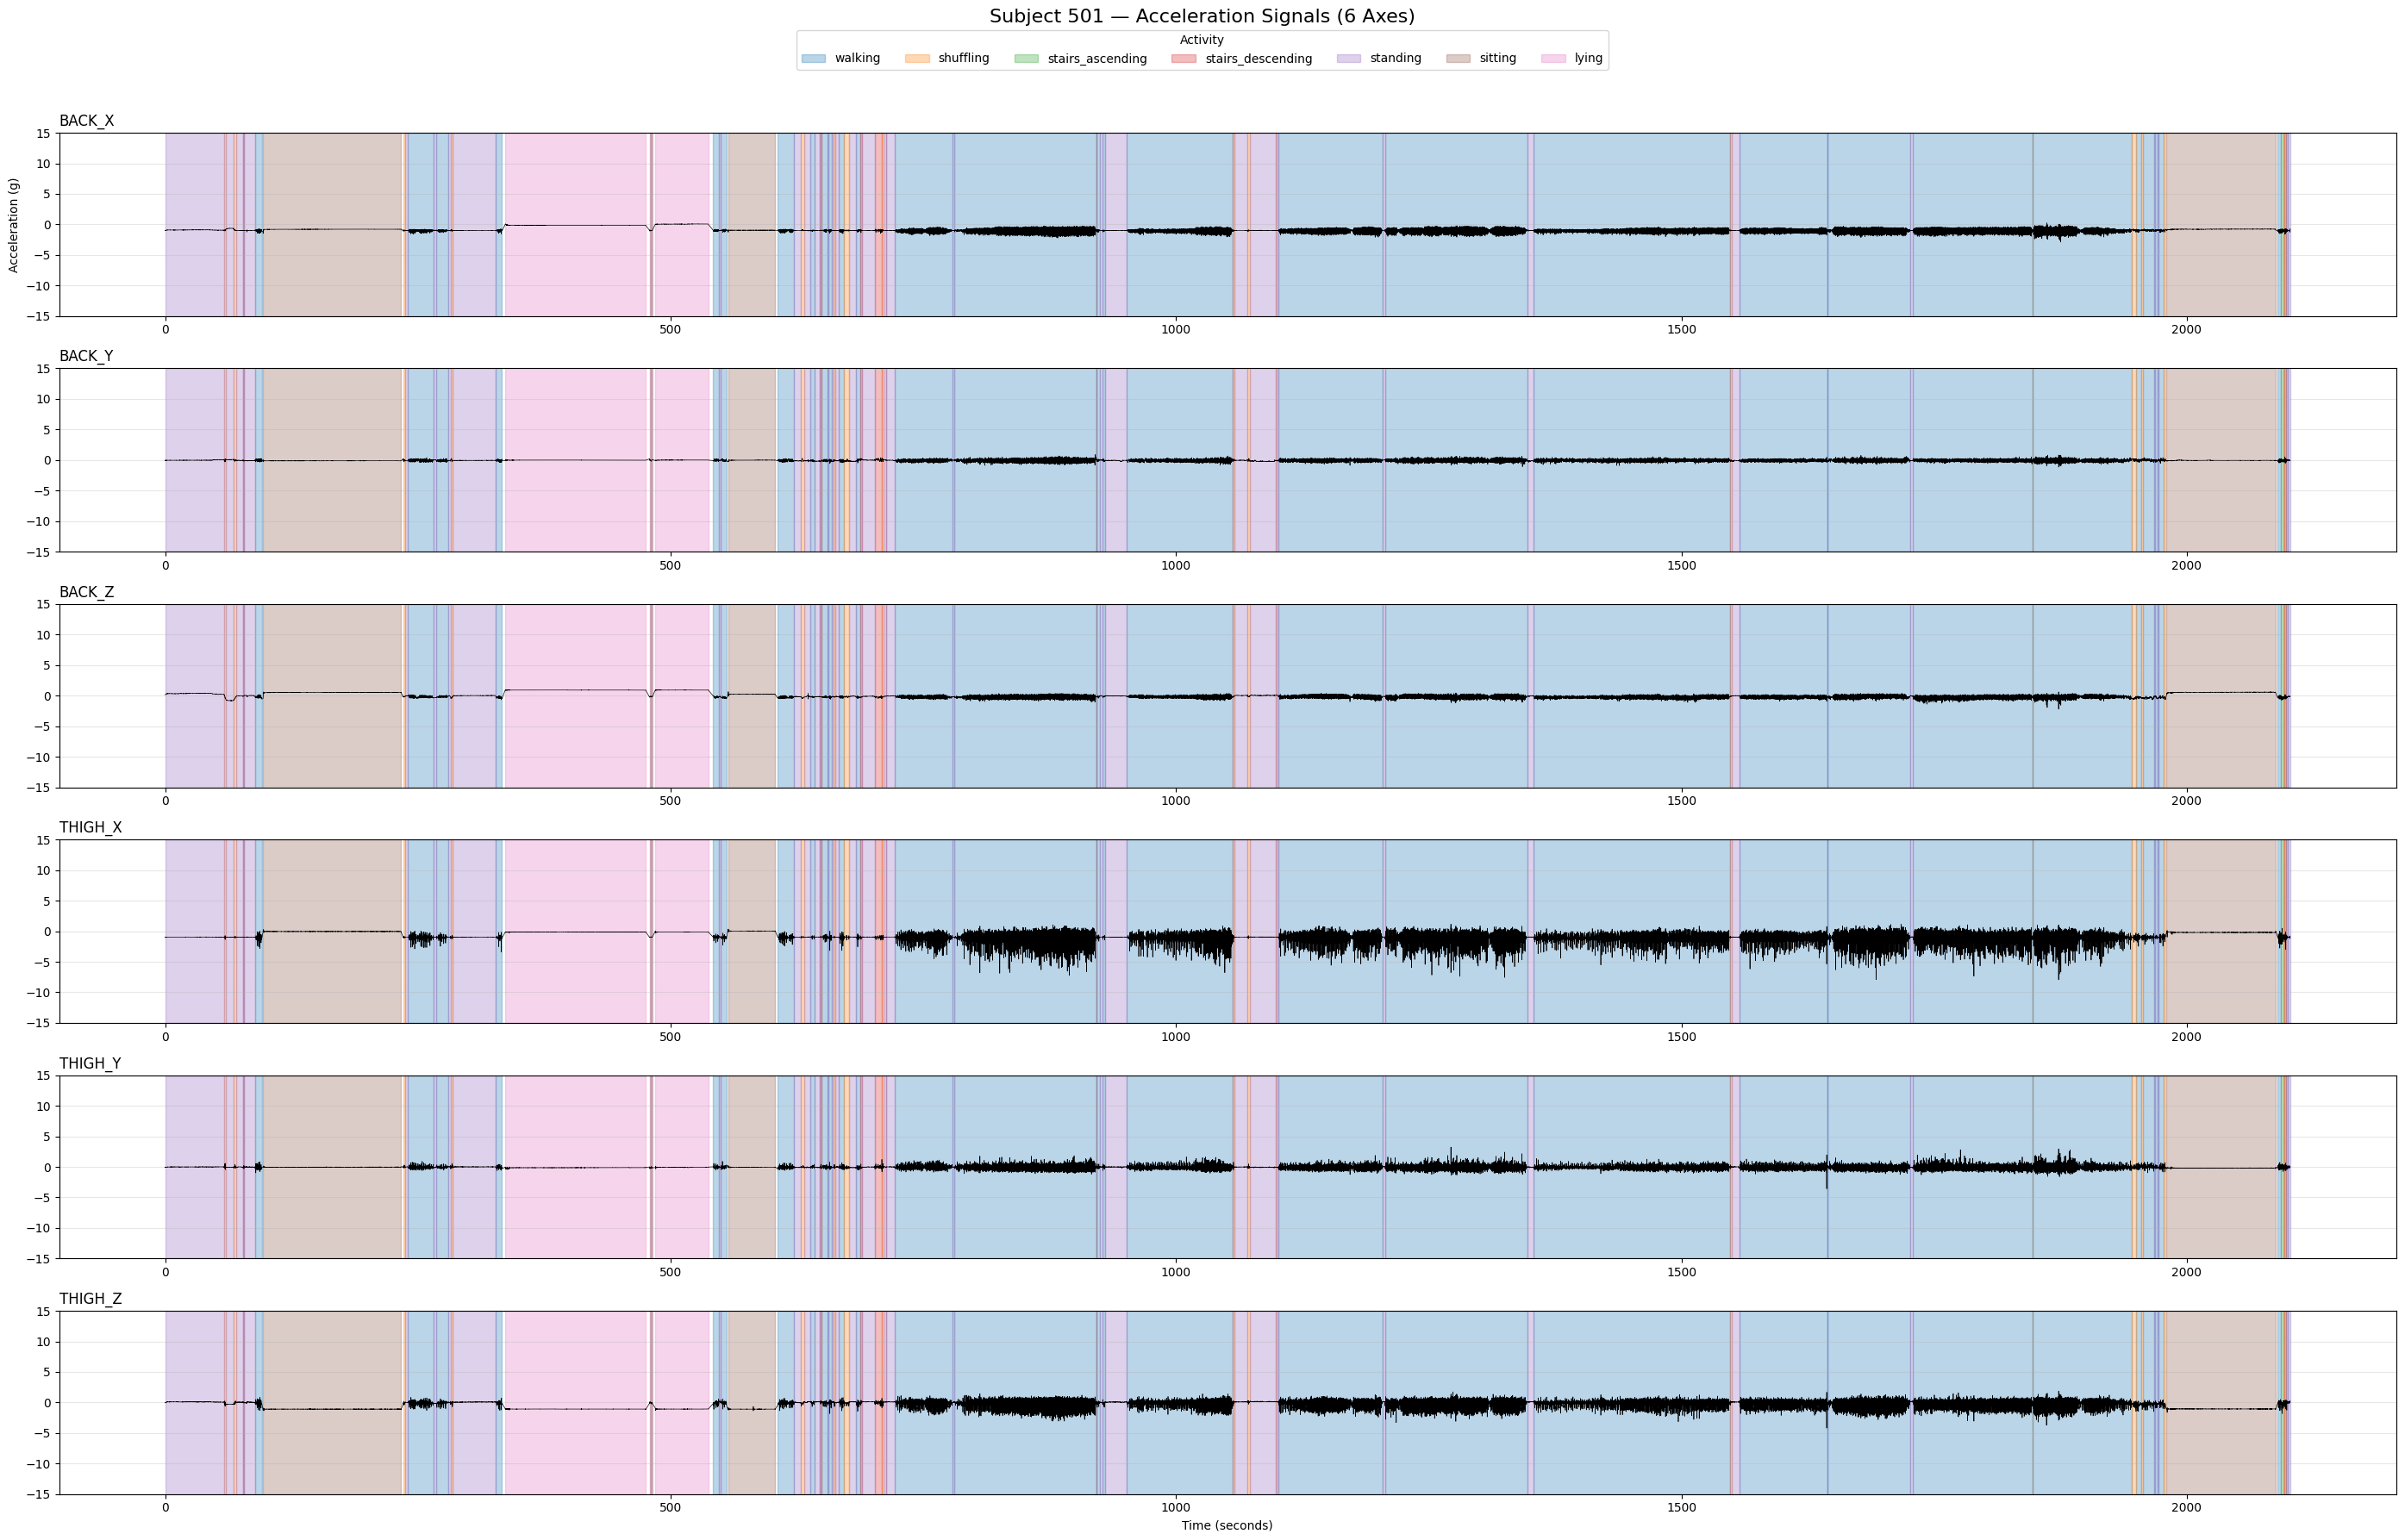

In [ ]:
plot_subject_6_axes(df=data, subject_id='501', label_map=label_map)

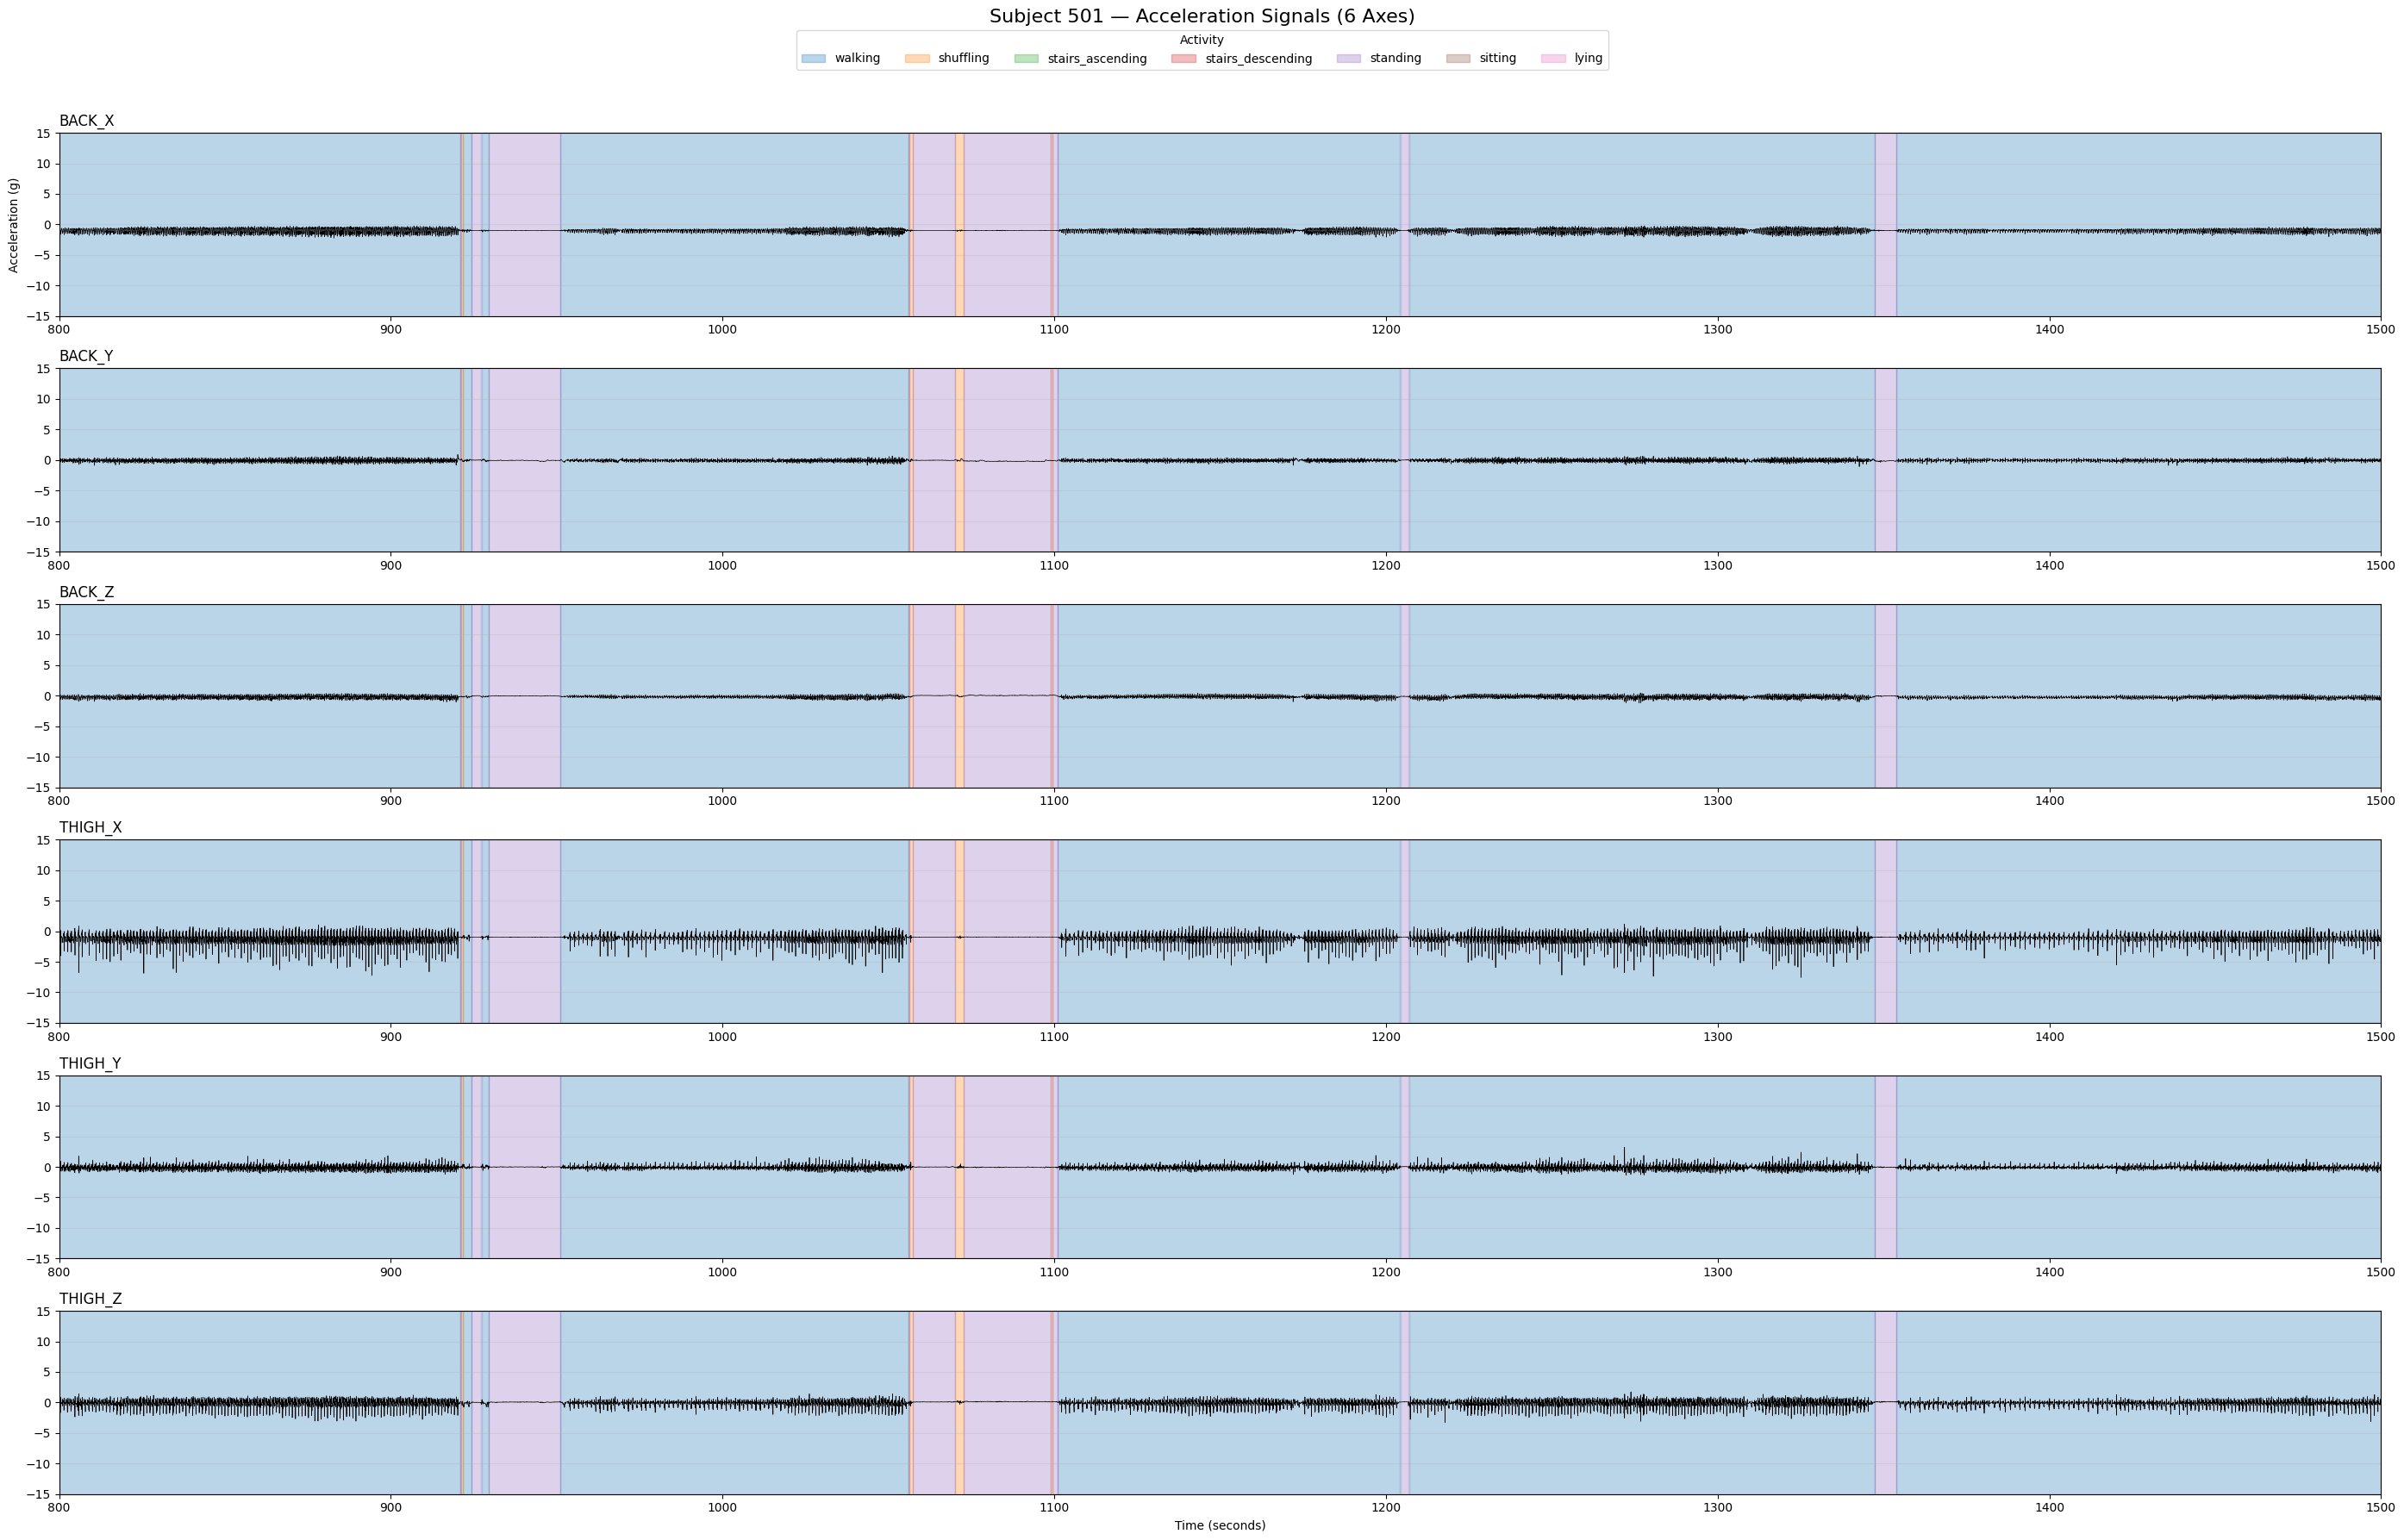

In [ ]:
# Plot with zoom
plot_subject_6_axes(df=data, subject_id='501', label_map=label_map, time_range=(800, 1500))

## **7. Feature Engineering**

The continuous signal is segmented into fixed-length, overlapping windows. This ensures that the model learns features from distinct, manageable periods of activity.

- **Window Parameters:** A window size of **10 seconds** (**500 samples** at 50 Hz) was used, with a 50% overlap (5 seconds / 250 samples).

- **Purpose of Overlap:** The **50% overlap** is essential to **minimize information loss** at activity transition points and improve classification robustness.

- **Data Integrity:** The windowing process was performed within subject and activity groups to prevent data leakage across boundaries.

In [ ]:
# Parameters
fs = 50                 # Sampling rate (Hz)
window_size_s = 10      # Window length (seconds)
step_size_s = 5         # 50% overlap

window_size = int(window_size_s * fs)  # 10s * 50Hz = 500 samples
step_size = int(step_size_s * fs)      # 5s * 50Hz = 250 samples

### 7.1) Feature Extraction Functions

- ### **Time-Domain**

This section defines functions to extract time-domain features from the accelerometer data, which help characterize the signal's patterns.

1. **Peak Zone Mean**: The peak_zone_mean function calculates the mean value of the signal's high-amplitude region, defined as values above a given percentile (default 90%). This feature highlights periods of intense movement, which are key for distinguishing the most dynamic activities, characterized by high signal amplitudes.

2. **Time-Domain Features**: The `extract_temp_features` function computes several features:

    - **Variance**: Measures signal stability; low variance indicates static activity.

    - **Skewness & Kurtosis**: Describe the asymmetry and peakedness of the signal, calculated only when variance is significant.

    - **Coefficient of Variation (CV)**: Helps identify activities with varying intensities.

    - **Zero-Crossing Rate (ZCR)**: Captures the frequency of signal changes, useful for differentiating between periodic and non-periodic activities.

These features provide a detailed description of the accelerometer signal, with Peak Zone Mean serving as a critical differentiator focused specifically on the magnitude of high-amplitude movement events that are crucial for accurate activity classification.

In [ ]:
def peak_zone_mean(x, percentile=90):
    """
    Computes the mean value of the high-amplitude region of the signal
    defined as values above a percentile of 90.
    """
    x_abs = np.abs(x)
    threshold = np.percentile(x_abs, percentile)
    peak_zone = x_abs[x_abs >= threshold]

    if len(peak_zone) == 0:
        return 0.0

    return np.mean(peak_zone)

In [ ]:
MIN_VARIANCE_THRESHOLD = 1e-6 # Threshold for variance

def extract_temp_features(x):
    x_centered = x - np.mean(x)  # Center the signal to focus on movement/vibration features
    variance = np.var(x_centered)   # Calculate variance to check stability

    if variance < MIN_VARIANCE_THRESHOLD:   # If variance is very low (static activity), moments are 0
        kurt_val = 0.0
        skew_val = 0.0
        cv_val = 0.0
    else:
        kurt_val = kurtosis(x_centered)     # Only calculate skew/kurtosis if variance is significant
        skew_val = skew(x_centered)
        cv_val = np.std(x_centered) / (np.mean(np.abs(x_centered)) + 1e-9)

    # Zero-Crossing Rate (count of sign changes)
    zero_crossings = np.sum(np.diff(np.sign(x_centered)) != 0)
    zcr_val = zero_crossings / len(x_centered)

    return {
       "mean": np.mean(x),
        "rms": np.sqrt(np.mean(x**2)),
        "std": np.std(x_centered),
        "median": np.median(x_centered),
        "peak_zone_mean": peak_zone_mean(x_centered, percentile=90),
        "skew": skew_val,
        "kurtosis": kurt_val,
        "cv": cv_val,
        "zcr": zcr_val
    }

- ### **Frequency-Domain**

This section defines functions for extracting frequency-domain features from the accelerometer signal. These features capture the signal's frequency components, which help distinguish different types of activity based on their spectral characteristics.

1. **Extracting Frequency Features**: The `extract_freq_features` function computes several key frequency-domain features:

    - **Dominant Frequency**: The mean frequency of the top 5 bins in the FFT, which represents the most dominant frequency components of the signal.

    - **Spectral Energy**: The sum of squared FFT values, indicating the total energy in the frequency domain.

    - **Spectral Entropy**: Measures the randomness or unpredictability of the signal's frequency distribution. It's particularly useful for distinguishing between similar activities like walking and shuffling. A higher entropy value typically indicates more chaotic or irregular movements.

2. **Power Spectral Density (PSD)**: The calculate_psd_vector function is implemented to compute the Power Spectral Density (PSD), which is essential for analyzing the frequency content of the accelerometer signal. The PSD describes how the power (energy) of a signal is distributed over a range of frequencies, returning both the frequency values and their corresponding PSD magnitudes.

The inclusion of the PSD vector is a highly recommended and robust strategy in HAR projects due to its ability to capture the inherent rhythmic and frequency structure of the human movement signal. Utilizing the entire PSD vector transforms the signal's frequency profile into a robust, high-dimensional representation. This strategy allows the classification model to learn the specific importance of every frequency band for accurate activity discrimination, providing richer information than scalar frequency features alone.

These frequency-domain features provide insights into the periodic and aperiodic components of the signal, helping to differentiate between dynamic activities based on their frequency characteristics.

In [ ]:
def extract_freq_features(x, fs):
    N = len(x)
    x_centered = x - np.mean(x)

    freqs = rfftfreq(N, d=1/fs)          # FFT computation
    fft_vals = np.abs(rfft(x_centered))
    fft_vals_norm = fft_vals / N         # Normalize FFT

    top_bins = np.argsort(fft_vals_norm)[-5:]
    dom_freq_mean = np.mean(freqs[top_bins])    # Dominant frequency (mean of top 5 bins)

    spec_energy = np.sum(fft_vals_norm**2)      # Spectral energy

    # Spectral Entropy (trying to solve walking vs shuffling)
    psd_vals = (fft_vals**2) / N            # Power Spectral Density (PSD)
    sum_psd = np.sum(psd_vals)

    if sum_psd == 0:
        spec_entropy = 0.0
    else:
        psd_norm = psd_vals / sum_psd
        spec_entropy = entropy(psd_norm[psd_norm > 0])

    return {
        "dom_freq": dom_freq_mean,
        "spec_energy": spec_energy,
        "spec_entropy": spec_entropy
    }


In [ ]:
def calculate_psd_vector(x, fs):
    N = len(x)
    x_centered = x - np.mean(x)
    # Frequencies
    freqs = rfftfreq(N, d=1/fs)
    # FFT (Amplitude)
    fft_vals = np.abs(rfft(x_centered))

    psd_vals = (fft_vals / N) ** 2  # Normalize by number of samples

    return freqs, psd_vals

- ### **Sliding Windows and Norm**

This section defines functions for creating sliding windows and calculating the norm (magnitude) of sensor data, which are essential for feature extraction in time-series analysis.

1. **Sliding Windows**: The `sliding_windows` function generates overlapping windows from the signal. Each window has a fixed size (`window_size`) and is shifted by a defined step (`step_size`). These windows allow the model to learn from smaller, sequential portions of the data, capturing temporal patterns in a manageable format.

2. **Vector Magnitude (L2 Norm)**: The `calculate_norm` function calculates the magnitude of the accelerometer signal for each sensor (x, y, z axes) using the **L2 norm** (Euclidean norm). This is done by taking the square root of the sum of the squared values from all three axes. The result provides a single value representing the overall acceleration, which simplifies the analysis of movement by combining the data from all axes into one feature.

These operations are crucial for segmenting the data into smaller, manageable windows and for obtaining a unified representation of the accelerometer signals. This prepares the data for further feature extraction and model training.

In [ ]:
# Generate overlapping sliding windows
def sliding_windows(signal, window_size, step_size):
    windows = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal[start:end])
    return windows

In [ ]:
# Calculate vector magnitude (L2 Norm) for a sensor
def calculate_norm(df_group, axes_prefix):
    x = df_group[f"{axes_prefix}_x"].values
    y = df_group[f"{axes_prefix}_y"].values
    z = df_group[f"{axes_prefix}_z"].values

    # Magnitude: sqrt(x^2 + y^2 + z^2)
    return np.sqrt(x**2 + y**2 + z**2)

### 7.2) Feature Extraction

The `extract_features_psd` function extracts both time-domain and frequency-domain features from the accelerometer data using sliding windows and Power Spectral Density (PSD). It divides the data into overlapping windows for each subject and activity, allowing the model to focus on smaller, sequential portions of the data. For each window, the **L2 norm** is calculated for the back and thigh sensors, combining the x, y, and z axes into a single feature representing overall acceleration. Time-domain features, such as mean and standard deviation, along with frequency-domain features like dominant frequency and spectral energy, are extracted. The **PSD vector** is then computed for each window to represent the power distribution across different frequencies. The function returns a dataframe of these extracted features and PSD vectors, along with the frequency values corresponding to the PSD.

This comprehensive feature extraction process provides detailed information that is crucial for analyzing and classifying the accelerometer data.

In [ ]:
def extract_features_psd(df):
    features_list = []
    psd_vectors_list = []
    all_cols = sensor_cols + ["back_norm", "thigh_norm"]

    freqs = None    # to store vector of frequencies

    for (subject, activity), g in df.groupby(["subject", "activity_name"]):
        g = g.copy()
        g["back_norm"]  = calculate_norm(g, "back")
        g["thigh_norm"] = calculate_norm(g, "thigh")

        windows = {c: sliding_windows(g[c].values, window_size, step_size) for c in all_cols}
        n_win = len(windows[all_cols[0]])

        for i in range(n_win):
            row = {"subject": subject, "activity": activity}
            psd_row = {"subject": subject, "activity": activity, "window_id": i}

            for c in all_cols:
                x = windows[c][i]

                # Extract escalar features
                row.update({f"{c}_{k}": v for k, v in extract_temp_features(x).items()})
                row.update({f"{c}_{k}": v for k, v in extract_freq_features(x, fs).items()})

                # Extract PSD vector
                current_freqs, psd_vector = calculate_psd_vector(x, fs)

                # Store frequencies (on first iteration only)
                if freqs is None:
                    freqs = current_freqs
                psd_row[f"psd_{c}"] = psd_vector

            features_list.append(row)
            psd_vectors_list.append(psd_row)
    return pd.DataFrame(features_list), pd.DataFrame(psd_vectors_list), freqs


The **similarity features** are added to capture how closely a given segment of data (represented by its PSD vector) matches the typical frequency characteristics of different activities. These features are computed by calculating the **Euclidean distance** between the PSD vector of the current window and the mean PSD vector for each activity.

The purpose of these similarity features is to help the model distinguish between activities based on their frequency content. By measuring the similarity of the current window to each activity’s typical frequency profile, the model can learn to classify activities based on both the time-domain and frequency-domain characteristics.

We include these similarity features because they enhance the model's ability to recognize subtle differences between activities that might not be easily distinguishable using only time-domain features. For example, activities like walking and shuffling may have similar time-domain characteristics but different frequency profiles, and these similarity features help the model capture that difference.

In [ ]:
def calculate_similarity_features(row, mean_psd_dict, all_activities, psd_cols):
    similarity_features = {}

    for col in psd_cols:
        psd_vector = row[col]

        for act in all_activities:
            mean_psd = mean_psd_dict[(act, col)]
            # Calculate Euclidean distance
            distance = euclidean(psd_vector, mean_psd)
            similarity_features[f"dist_{col[4:]}_to_{act}"] = distance

    return pd.Series(similarity_features)

In [ ]:
print("Extracting features for training set...")
features_train_base, psd_train_df, freqs_train = extract_features_psd(data_train)
print("Training features extracted: ", features_train_base.shape)

Extracting features for training set...
Training features extracted:  (7390, 98)


In [ ]:
print("Extracting features for test set...")
features_test_base, psd_test_df, freqs_test = extract_features_psd(data_test)
print("Test features extracted: ", features_test_base.shape)

Extracting features for test set...
Test features extracted:  (1491, 98)


This part of the code calculates the **mean PSD (Power Spectral Density)** for each activity and sensor, which serves as a reference for comparing individual PSD vectors. The mean PSD values are stored in `mean_psd_dict`.

Next, the **similarity features** are generated by calculating the **Euclidean distance** between the PSD vector of each window and the mean PSD for each activity. These features help the model compare how closely each signal matches the typical frequency profile of different activities.

Finally, the similarity features are added to the training and test datasets, enhancing the model’s ability to distinguish activities based on their frequency characteristics.

In [ ]:
mean_psd_dict = {}
all_activities = features_train_base['activity'].unique()
psd_cols = [c for c in psd_train_df.columns if c.startswith('psd_')]

for activity, group in psd_train_df.groupby('activity'):
    for col in psd_cols:
        mean_psd_dict[(activity, col)] = np.mean(np.stack(group[col].values), axis=0)

print("Mean Spectrum calculated for each Activity/Sensor.")

Mean Spectrum calculated for each Activity/Sensor.


In [ ]:
new_features_train = psd_train_df.apply(lambda row: calculate_similarity_features(row, mean_psd_dict, all_activities, psd_cols), axis=1)
features_train_final = pd.concat([features_train_base, new_features_train], axis=1)

new_features_test = psd_test_df.apply(lambda row: calculate_similarity_features(row, mean_psd_dict, all_activities, psd_cols), axis=1)
features_test_final = pd.concat([features_test_base, new_features_test], axis=1)

print("Final training features shape:", features_train_final.shape)

Final training features shape: (7390, 154)


## **8. Baseline Classification Model: Random Forest**

### 8.1) Prepare Data for Modeling


In this part of the code, we prepare the data for training the **Random Forest** model by first removing certain activities from the dataset. Specifically, we remove the "stairs_ascending" and "stairs_descending" activities. Due to severe class imbalance, the stair-related activities were removed from the dataset to ensure robust model generalization across the remaining five, more frequent activities.

Next, we separate the **features** and the **label**. The features (X) are all the columns in the dataset except for the identifiers like "subject", "activity", and "window_id", while the label (y) is the activity name.

To evaluate the model’s performance, we split the **training** data into training and **validation** sets. We use 80% of the data for training and 20% for validation. This helps us assess how well the model generalizes to unseen data during training. We also use **stratified splitting**, meaning the proportion of each activity class is preserved in both the training and validation sets, ensuring a balanced representation.

Finally, we scale the features using **StandardScaler**. This step standardizes the data by transforming it to have a mean of 0 and a standard deviation of 1. Scaling is important because some machine learning algorithms, like Random Forest, perform better when the features are on the same scale.

These steps ensure that the model is trained on clean, balanced data and that the features are properly normalized for better performance.

In [ ]:
CLASSES_TO_REMOVE = ["stairs_ascending", "stairs_descending"]
features_train = features_train_final[~features_train_final["activity"].isin(CLASSES_TO_REMOVE)]
features_test  = features_test_final[~features_test_final["activity"].isin(CLASSES_TO_REMOVE)]

X_train_full = features_train.drop(columns=["subject", "activity"])
y_train_full = features_train["activity"]

X_test = features_test.drop(columns=["subject", "activity"])
y_test = features_test["activity"]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,       # 20% of training pool for validation
    random_state=42,
    stratify=y_train_full # maintain class balance
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples (unseen subjects): {X_test.shape[0]}")

Training samples: 5902
Validation samples: 1476
Test samples (unseen subjects): 1490


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

### 8.2) Train Random Forest Classifier

In this part of the code, we train a **Random Forest Classifier**. The classifier is initialized with several parameters:

- `n_estimators=300` specifies the number of trees in the forest.

- `class_weight="balanced"` is used to handle class imbalance by adjusting the weights of the classes based on their frequency. This ensures that the model does not favor the more frequent classes.

- `random_state=42` ensures reproducibility by setting a fixed random seed.

- `n_jobs=-1` allows the training to use all available CPU cores, speeding up the training process.

Next, the model training is started by calling `fit(X_train, y_train)`, where `X_train` is the training data and `y_train` are the labels. The training time is measured using the `time()` function, and once the model is trained, the total time taken is printed.

This process allows us to build and train the Random Forest model, ensuring it can handle class imbalance and is trained efficiently using all available computational resources.

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nStarting Model Training...")
start_time = time()
rf_clf.fit(X_train, y_train)
end_time = time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")


Starting Model Training...
Training completed in 2.02 seconds.


### 8.3) Evaluate Model Performance

The Random Forest model is evaluated on the **validation set**. The model makes predictions using `X_val`, and the accuracy is calculated by comparing the predicted labels (`y_val_pred`) to the true labels (`y_val`). The validation accuracy is printed, showing how well the model performs on unseen data.

In this case, the model achieved a validation accuracy of **0.9898**, indicating excellent performance.

In [ ]:
y_val_pred = rf_clf.predict(X_val)
rf_val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {rf_val_accuracy:.4f}")


Validation Accuracy: 0.9898


The Random Forest model was rigorously evaluated on the **test set** (unseen subjects), achieving a high overall **Test Accuracy of $0.9711$**. This result confirms the model’s strong ability to generalize activity classification to new subjects.

**Classification Metrics Summary**

The model demonstrated **near-perfect performance** for most activities, particularly achieving flawless **Recall ($1.00$)** for the 'lying', 'standing', and 'walking' classes, and a perfect **F1-score ($1.00$)** for 'lying'.

However, the primary limitation was observed in classifying the **'shuffling'** activity, which had a distinctly low **Recall of $0.44$** (F1-score of $0.60$).


In [ ]:
y_test_pred_rf = rf_clf.predict(X_test)
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)
print(f"Test Accuracy (Unseen Subjects): {rf_test_accuracy:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf))

Test Accuracy (Unseen Subjects): 0.9711

Classification Report (Test Set):
              precision    recall  f1-score   support

       lying       1.00      1.00      1.00       152
   shuffling       0.96      0.44      0.60        55
     sitting       1.00      0.97      0.98       261
    standing       0.90      1.00      0.95       247
     walking       0.98      1.00      0.99       775

    accuracy                           0.97      1490
   macro avg       0.97      0.88      0.90      1490
weighted avg       0.97      0.97      0.97      1490



A **confusion matrix** is generated to evaluate the **Random Forest model's** performance on the test set with unseen subjects. The confusion matrix shows how well the model’s predictions match the true activity labels.

Each row of the matrix represents the true activity, while each column represents the predicted activity. The values along the diagonal show the correct predictions, while the off-diagonal values indicate misclassifications.

**Analysis of Misclassification**

The Confusion Matrix visually confirms that the vast majority of errors involve the 'shuffling' class (True Label 1). **31 samples** of true 'shuffling' were misclassified, specifically being incorrectly assigned to:
* **'Standing'** (17 samples)
* **'Walking'** (14 samples)

**Justification for Misclassification:**

The difficulty in correctly classifying 'shuffling' is attributed to its **low-amplitude and ambiguous rhythmic characteristics**, which blur the feature boundary between other postural activities:

1.  **Confusion with Standing:** 'Shuffling' often entails very small, hesitant movements. The overall low magnitude and lack of a strong, distinct rhythm cause the signal features to closely resemble the static profile of **'standing'**.
2.  **Confusion with Walking:** When the shuffling steps are slightly faster or larger, the energy profile (captured by the PSD and L2 Norm) can mimic a slow or hesitant form of **'walking'**.

This suggests that the features extracted, while effective for high-energy and static activities, lack the granularity to robustly distinguish the subtle temporal structure inherent to 'shuffling'.

Overall, the model performs well with high accuracy and balanced performance across classes.

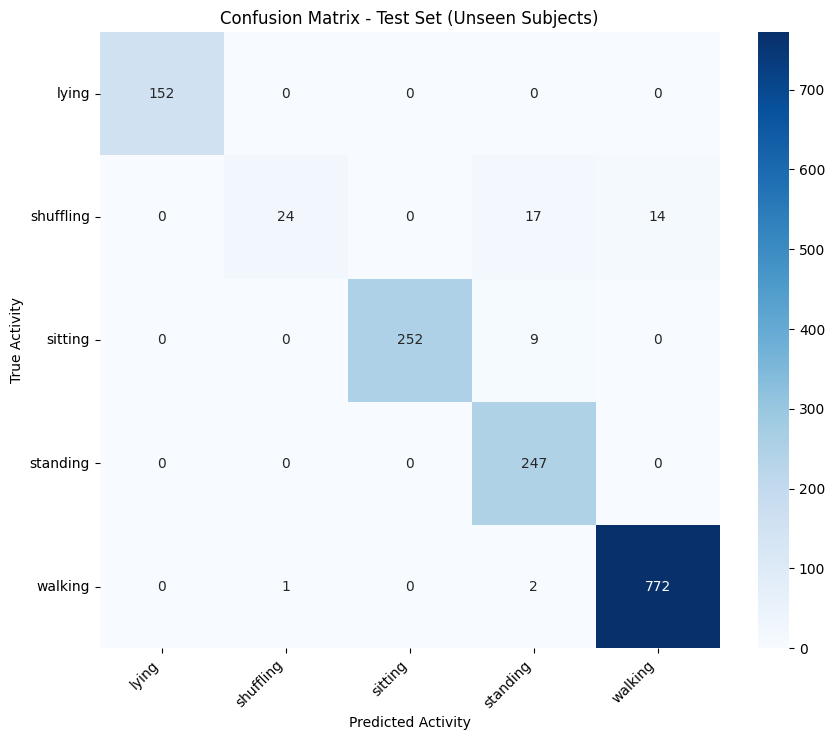

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_rf, labels=rf_clf.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_clf.classes_, yticklabels=rf_clf.classes_)
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.title("Confusion Matrix - Test Set (Unseen Subjects)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

Finally, **feature importance analysis** is performed to identify which features have the most significant impact on the **Random Forest** model’s predictions. The `feature_importances_` attribute of the trained `RandomForestClassifier` is used to obtain the importance scores for each feature.

The **importance scores** are based on the **Gini impurity** measure, which reflects how well each feature helps in splitting the data to improve classification accuracy. The higher the score, the more important the feature is for the model.

The top 20 most important features are visualized in a bar plot, showing the relative importance of each feature for **Human Activity Recognition (HAR)** classification.

The **top 5 features** are printed out with their corresponding importance scores.

The analysis of feature importance reveals that the most critical features for classifying activities predominantly reside in the **time-domain mean values** and **overall magnitude** (Root Mean Square (RMS) / Vector Norm Mean) of the acceleration signals.

The top five most important features are dominated by:

1.  **Mean Acceleration:** The top three features are the mean values of the **Thigh X, Back X, and Thigh Z** axes.
2.  **Overall Magnitude:** Features capturing the overall signal magnitude across all axes (like **Back Norm Mean** and **Back X RMS**) are also highly ranked.

This outcome strongly suggests that the Random Forest model is primarily utilizing **posture and static orientation**—features inherent to the mean and RMS calculation—to differentiate between activities:

* **Posture Discrimination (Mean Values):** The mean acceleration on specific axes (e.g., $X$ and $Z$) is the clearest indicator of the sensor's static orientation relative to gravity ($1g$). Since the thigh and back sensors change their resting angles significantly between activities like *lying*, *sitting*, and *standing*, these mean values act as powerful discriminators for **postural recognition**.
* **Energy and Intensity (RMS/Norm Mean):** The RMS and the vector Norm Mean capture the average magnitude of the overall signal and the intensity of the movement. These features are crucial for distinguishing between static activities (low magnitude) and dynamic activities like *walking* (high magnitude).

In essence, the model relies heavily on the **static and low-frequency components** of the signal to establish the subject's fundamental body position, which simplifies the classification task significantly. The highly effective feature engineering focused on time-domain statistics has successfully provided the model with the most direct information needed for accurate classification.


--- Feature Importance Analysis (Top 20) ---


C:\Users\beatr\AppData\Local\Temp\ipykernel_29072\4112263278.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(20), x="importance", y="feature", palette="viridis")


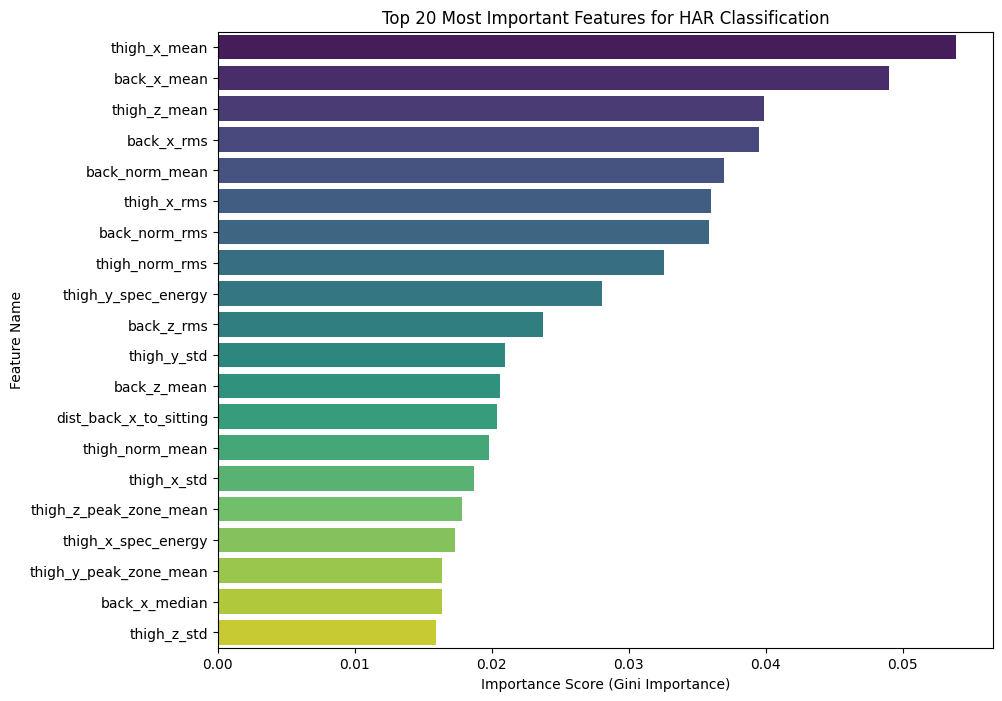


Top 5 Features:
          feature  importance
0    thigh_x_mean    0.053887
1     back_x_mean    0.049022
2    thigh_z_mean    0.039836
3      back_x_rms    0.039540
4  back_norm_mean    0.036938


In [ ]:
print("\n--- Feature Importance Analysis (Top 20) ---")

importances = rf_clf.feature_importances_
feature_names = X_train_full.columns

feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df.head(20), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Most Important Features for HAR Classification")
plt.xlabel("Importance Score (Gini Importance)")
plt.ylabel("Feature Name")
plt.show()

print("\nTop 5 Features:")
print(feat_imp_df.head(5))

## **9. Sensitivity Analysis and Model Robustness**

This section explores how varying key parameters affects the validation performance of the model. The baseline pipeline remains unchanged, ensuring that only one parameter is varied at a time. The purpose is to test different values for each hyperparameter, compare the results, and identify the optimal values that improve performance.

It's important to note that the **test set** is never used for hyperparameter tuning, ensuring that the model's generalization ability is properly evaluated.

This process helps ensure the robustness of the model and its ability to adapt to different configurations.

### 9.1) Evaluation of Hyperparameters



We perform **hyperparameter tuning** to examine how different values for key parameters affect model performance. We use **Grid Search** with **5-fold cross-validation** to search for the best combination of hyperparameters for the **Random Forest Classifier**.

The hyperparameters tested include:

- `n_estimators`: The number of trees in the forest (100, 200, or 300).

- `max_depth`: The maximum depth of the trees (None, 10, or 20).

- `min_samples_split`: The minimum number of samples required to split an internal node (2, 5, or 10).

- `min_samples_leaf`: The minimum number of samples required to be at a leaf node (1, 2, or 4).

In [ ]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

y_val_pred_grid = grid_search.predict(X_val)
val_accuracy_grid = accuracy_score(y_val, y_val_pred_grid)
print("Validation Accuracy with Best Hyperparameters:", val_accuracy_grid)

y_test_pred_grid = grid_search.predict(X_test)
test_accuracy_grid = accuracy_score(y_test, y_test_pred_grid)
print("Test Accuracy with Best Hyperparameters:", test_accuracy_grid)

best_params = grid_search.best_params_

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 0.9896648918612495
Validation Accuracy with Best Hyperparameters: 0.9905149051490515
Test Accuracy with Best Hyperparameters: 0.9724832214765101


For this case, the best hyperparameters were found to be:

- `n_estimators` = 200

- `max_depth` = None

- `min_samples_split` = 5

- `min_samples_leaf` = 2

With these hyperparameters, the **validation accuracy** was **0.9905**, and the **test accuracy** was **0.9725**, indicating that the model performs well on both the validation and test sets.

This hyperparameter tuning ensures that the model is optimized for the best performance, and the results from this step will be used for further sensitivity analysis.

### 9.2) Effect of Window Size

In this section, we evaluate the impact of **window size** on model performance. The analysis tests three different window sizes: 5s, 10s, and 15s. The purpose of this sensitivity analysis is to identify how the size of the windows used for feature extraction affects the validation accuracy.

For each window size:

1. The global window size and step size are adjusted.

2. **Feature extraction** is performed again, including the calculation of **mean PSD** and **similarity features** for each window.

3.  The data is cleaned, removing irrelevant activity classes, and then split into **training** and **validation** sets.

4. The **Random Forest model** is trained using the best hyperparameters found in the previous step, and the validation accuracy is recorded.

The results of this analysis are displayed in a table, showing how the validation accuracy changes with different window sizes. Based on the output, we can see that as the window size increases from 5s to 15s, the validation accuracy improves, reaching its highest at 15s.

This analysis helps to determine the optimal window size for the classification task, balancing feature richness and computational efficiency.

In [ ]:
print("\n--- Sensitivity Analysis: Window Size ---")

window_size_candidates_s = [5, 10, 15]
baseline_step_s = 5
window_size_results = []

# Using Best Params found in the previous cell
rf_best_params = grid_search.best_params_
print(f"Using Best RF Hyperparameters: {rf_best_params}")

for win_s in window_size_candidates_s:
    print(f"\nTesting window size: {win_s}s")

    # Redefine global window_size and step_size
    global window_size, step_size
    window_size = int(win_s * fs)
    step_size = int(baseline_step_s * fs)

    # Extract all features (Base + PSD Vectors)
    features_train_base_tmp, psd_train_df_tmp, _ = extract_features_psd(data_train)

    # Recalculate Mean PSD and Similarity Features
    mean_psd_dict_tmp = {}
    all_activities_tmp = features_train_base_tmp['activity'].unique()
    psd_cols_vectors_tmp = [c for c in psd_train_df_tmp.columns if c.startswith('psd_')]

    # Calculate Mean PSD for Training Features
    for activity, group in psd_train_df_tmp.groupby('activity'):
        for col in psd_cols_vectors_tmp:
            mean_psd_dict_tmp[(activity, col)] = np.mean(np.stack(group[col].values), axis=0)

    # Generate and Concatenate Similarity Features
    new_features_train_tmp = psd_train_df_tmp.apply(lambda row: calculate_similarity_features(row, mean_psd_dict_tmp, all_activities_tmp, psd_cols_vectors_tmp), axis=1)
    features_train_final_tmp = pd.concat([features_train_base_tmp.reset_index(drop=True), new_features_train_tmp.reset_index(drop=True)], axis=1)


    features_train_clean_tmp = features_train_final_tmp[~features_train_final_tmp["activity"].isin(CLASSES_TO_REMOVE)].copy()

    columns_to_drop_tmp = ["subject", "activity"] + psd_cols_vectors_tmp
    if 'window_id' in features_train_clean_tmp.columns:
        columns_to_drop_tmp.append('window_id')

    X_train_tmp = features_train_clean_tmp.drop(columns=columns_to_drop_tmp, errors='ignore')
    y_train_tmp = features_train_clean_tmp["activity"]

    # Split into Training/Validation (for the current window size)
    X_tr, X_val_tmp, y_tr, y_val_tmp = train_test_split(
        X_train_tmp, y_train_tmp,
        test_size=0.2,
        random_state=42,
        stratify=y_train_tmp
    )

    rf_tmp = RandomForestClassifier(**rf_best_params, class_weight="balanced", random_state=42, n_jobs=-1)
    rf_tmp.fit(X_tr, y_tr)

    y_val_pred_tmp = rf_tmp.predict(X_val_tmp)
    val_acc_tmp = accuracy_score(y_val_tmp, y_val_pred_tmp)

    window_size_results.append((win_s, val_acc_tmp))
    print(f"Validation Accuracy: {val_acc_tmp:.4f}")

window_size_df = pd.DataFrame(window_size_results, columns=["Window Size (s)", "Validation Accuracy"])
display(window_size_df)


--- Sensitivity Analysis: Window Size ---
Using Best RF Hyperparameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Testing window size: 5s
Validation Accuracy: 0.9805

Testing window size: 10s
Validation Accuracy: 0.9912

Testing window size: 15s
Validation Accuracy: 0.9945


,Window Size (s),Validation Accuracy
0,5,0.980550
1,10,0.991192
2,15,0.994524


### 9.3) Best Model

The **final Random Forest model** is trained using the optimal **window size** and **hyperparameters** found during the previous steps.

The model is first initialized with the best parameters from the grid search (`rf_best_params`), and the training set is used to train the final model. After training, the model is evaluated on the **test set**. The **test accuracy** is reported, and a detailed **classification report** is provided, showing the model's performance in terms of **precision**, **recall**, and **f1-score** for each activity class.

Additionally, a **confusion matrix** is generated to visualize how the model predicted each activity compared to the true labels.


Training final Random Forest model with optimal Window Size and Hyperparameters...

=== FINAL MODEL PERFORMANCE ===
Optimal Window Size Used: 15.0s
Test Accuracy: 0.9725

Classification Report (F1-Score, Precision, Recall):
              precision    recall  f1-score   support

       lying       1.00      1.00      1.00       152
   shuffling       0.88      0.53      0.66        55
     sitting       1.00      0.97      0.98       261
    standing       0.90      1.00      0.95       247
     walking       0.99      0.99      0.99       775

    accuracy                           0.97      1490
   macro avg       0.95      0.90      0.92      1490
weighted avg       0.97      0.97      0.97      1490


Confusion Matrix:


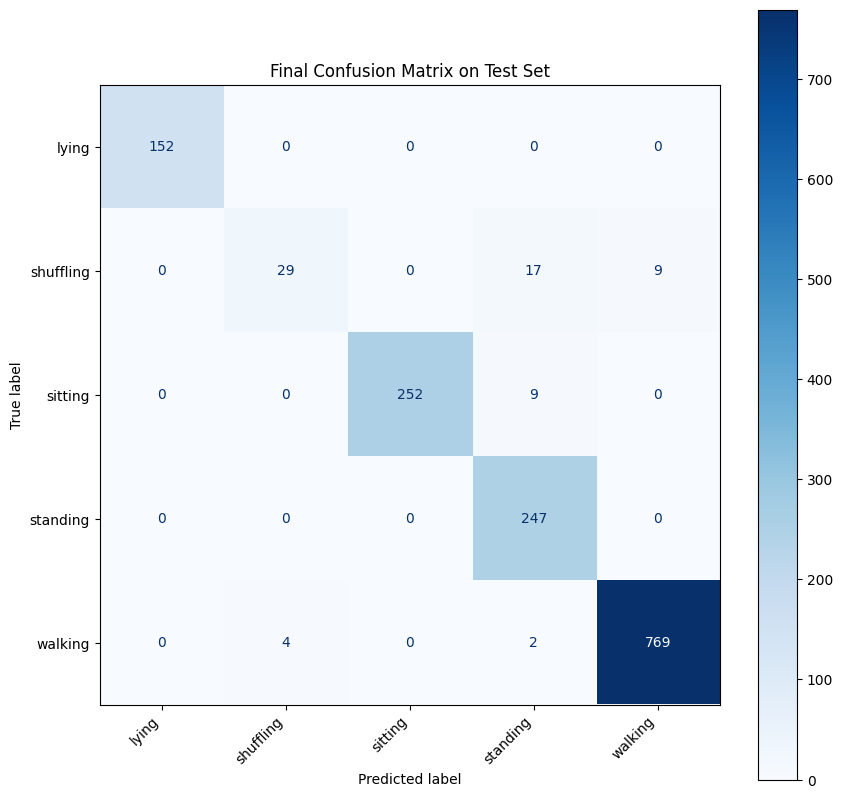

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

rf_best_params = grid_search.best_params_
rf_final = RandomForestClassifier(**rf_best_params,
                                  class_weight="balanced",
                                  random_state=42,
                                  n_jobs=-1)

if 'window_size' in globals():
    win_size_s_final = window_size / fs
elif 'window_size_df' in globals() and not window_size_df.empty:
    win_size_s_final = window_size_df.iloc[0]["Window Size (s)"]
else:
    win_size_s_final = "Optimal"


print("Training final Random Forest model with optimal Window Size and Hyperparameters...")

rf_final.fit(X_train, y_train)

y_test_pred_final = rf_final.predict(X_test)
test_accuracy_final = accuracy_score(y_test, y_test_pred_final)

print("\n=== FINAL MODEL PERFORMANCE ===")
print(f"Optimal Window Size Used: {win_size_s_final}s")
print(f"Test Accuracy: {test_accuracy_final:.4f}")

print("\nClassification Report (F1-Score, Precision, Recall):")
print(classification_report(y_test, y_test_pred_final, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred_final, labels=rf_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_final.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Final Confusion Matrix on Test Set")
plt.xticks(rotation=45, ha='right')
plt.show()

Even after hyperparameter tuning, the confusion matrix representing the Random Forest model's performance on the test set, show **nearly identical classification results**.

The total number of correct and incorrect predictions for almost all activities (Lying, Sitting, Standing, and Walking) is invariant across the two matrices. The main error source, **'shuffling,'** also shows minimal variation (e.g., $24$ correct predictions in one matrix vs. $29$ in the other, with similar totals for misclassification).

This stability indicates that the model's performance has reached a **performance ceiling dictated by the feature set**, not by the internal structure of the model:

1.  **Feature Saturation:** The initial Random Forest model (before tuning) was already robust and complex enough to extract nearly all the predictive information available in the *current feature set* (time-domain means, PSD vector, etc.).
2.  **Optimal Decision Boundaries:** The most effective decision boundaries, particularly for distinguishing the highly separable classes (like **lying** and **walking**), are clearly defined by the powerful **postural features** (e.g., mean acceleration). Hyperparameter tuning could not improve these near-perfect boundaries any further.
3.  **Ambiguity Limit:** The persistent misclassification of the **'shuffling'** activity confirms the performance limit. This error is not caused by suboptimal hyperparameters, but by the **inherent ambiguity in the features** for that specific, low-amplitude activity. No amount of tuning can resolve a feature ambiguity; it requires new, more descriptive features or a different type of model (e.g., sequence-based deep learning) that is sensitive to temporal dependencies.

**Conclusion:**

The hyperparameter tuning successfully confirmed that the **original model was already operating near its optimal capacity** given the data and feature engineering approach. The lack of significant improvement post-tuning suggests that to achieve higher accuracy, the focus must shift from *optimizing the model* to **enhancing the feature representation**.

## **10. Alternative Model: Support Vector Machine (SVM)**

Following the initial assessment using the Random Forest classifier, a Support Vector Machine (SVM) was trained as a comparative model. This step was crucial to evaluate the robustness and performance generalization across different learning paradigms, specifically contrasting the decision-tree ensemble approach with a kernel-based maximum margin classifier.

### 10.1) Train SVM Model Classifier

In this section, we train a **Support Vector Machine (SVM)** classifier with an **RBF kernel**, regularization parameter **C=10**, and **balanced class weights** to handle class imbalance. The model is trained on the **training data** (`X_train`, `y_train`) to evaluate its performance as an alternative to the Random Forest model.

In [ ]:
svm_clf = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

In [ ]:
svm_clf.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


### 10.2) Evaluate Model Performance

In this part, the **SVM model** is evaluated on the **test set**. The model makes predictions using `X_test`, and the **accuracy** is calculated by comparing the predicted labels (`y_test_pred_svm`) to the true labels (`y_test`). The resulting **SVM test accuracy** is printed, showing a value of **0.9705**.

Additionally, a **classification report** is generated, which provides detailed metrics such as **precision**, **recall**, and **f1-score** for each activity.

The model performs very well for activities like **lying**, **sitting**, and **walking** with high scores, but it has slightly lower performance on **shuffling**, with precision and recall around **0.77** and **0.60**, respectively. This indicates that the model struggles more with identifying shuffling compared to other activities.

In [ ]:
y_test_pred_svm = svm_clf.predict(X_test)

svm_acc = accuracy_score(y_test, y_test_pred_svm)

print("SVM Test Accuracy:", svm_acc)
print(classification_report(y_test, y_test_pred_svm))

SVM Test Accuracy: 0.9704697986577181
              precision    recall  f1-score   support

       lying       1.00      0.95      0.98       152
   shuffling       0.77      0.60      0.67        55
     sitting       0.97      0.98      0.98       261
    standing       0.92      1.00      0.96       247
     walking       0.99      0.99      0.99       775

    accuracy                           0.97      1490
   macro avg       0.93      0.90      0.92      1490
weighted avg       0.97      0.97      0.97      1490



The comparison between the **Random Forest** and **SVM (RBF)** models shows that both models performed similarly on the test set. The **Random Forest** model achieved a test accuracy of **0.9711**, while the **SVM (RBF)** model had a test accuracy of **0.9705**.

This indicates that both models are effective for the task, with Random Forest performing slightly better. Despite this small difference, both models provide strong results, and either could be used depending on the specific requirements of the project.

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "SVM (RBF)"],
    "Test Accuracy": [rf_test_accuracy, svm_acc]
})

comparison_df

,Model,Test Accuracy
0,Random Forest,0.971141
1,SVM (RBF),0.970470


In this part, **confusion matrices** are displayed for both the **Random Forest** and **SVM (RBF)** models. These matrices provide a detailed view of how the models classified the activities in the **test set**.

- **Random Forest** shows excellent performance, with most activities being correctly predicted. There are some misclassifications for shuffling (with 17 samples misclassified as walking) and walking (with 1 sample misclassified as shuffling).

- **SVM (RBF)** also performs well, but there are slightly more misclassifications, particularly for shuffling, which has 7 misclassified as walking, and sitting, with 9 misclassified as walking.

Both models perform well in identifying activities like **lying**, **sitting**, and **standing**, but **shuffling** remains a challenging activity for both models, as reflected in the confusion matrices.

Text(0.5, 1.0, 'SVM (RBF)')

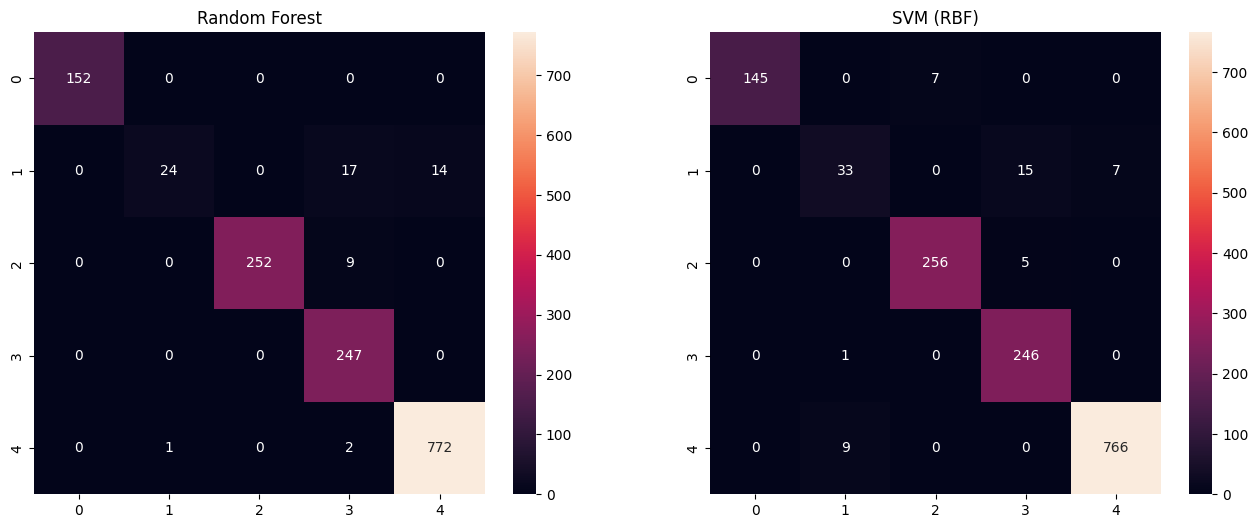

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(y_test, y_test_pred_rf),
            annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Random Forest")

sns.heatmap(confusion_matrix(y_test, y_test_pred_svm),
            annot=True, fmt="d", ax=axes[1])
axes[1].set_title("SVM (RBF)")

## **11. Conclusion and Future Work**

## Conclusion

This project successfully developed highly effective Human Activity Recognition (HAR) classifiers using accelerometer data, demonstrating the power of robust feature engineering.

Both the **Random Forest (RF)** and **Support Vector Machine (SVM) with an RBF kernel** achieved exceptionally strong performance with near-identical test accuracies (RF: **0.9711** vs. SVM: **0.9705**).

### Model Selection and Performance Analysis

The detailed classification metrics indicate that the **Random Forest** model is the **most suitable classifier for deployment** in this specific HAR context.

While both models achieved an overall accuracy of $97\%$, the Random Forest demonstrated a **superior and more balanced performance** in distinguishing static and common activities, achieving a perfect **$1.00$ F1-score for 'lying'** and a higher **$1.00$ precision for 'sitting'** compared to the SVM.

The primary limitation identified across both models was the challenge in accurately classifying the **'shuffling'** activity, which experienced the highest misclassification rates:

* **RF:** Achieved an F1-score of **$0.66$** (Precision: $0.88$, Recall: $0.53$).
* **SVM:** Performed marginally worse, achieving an F1-score of **$0.67$** (Precision: $0.77$, Recall: $0.60$).

Despite the struggle with 'shuffling,' the high performance of both models underscores the critical success of the **feature engineering strategy**, which included specialized **time-domain**, **frequency-domain**, and **PSD similarity features**, optimized using a **15-second window size**.

### Future Work

Future work should prioritize targeted feature engineering or the exploration of sequence-based deep learning models to specifically address the low recall and precision observed in the **'shuffling'** activity, aiming to achieve perfect classification accuracy across all target classes.